In [3]:
import pyspedas
import pytplot
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.cm as cm

import scipy
from scipy import interpolate,optimize
from scipy.optimize import curve_fit
from skimage.transform import probabilistic_hough_line

In [4]:
start = '2023-01-03'
end = '2023-01-04'
time_clip = True
no_update = False
varnames_hfr = 'psp_fld_l3_rfs_hfr_auto_averages_ch0_V1V2'
varnames_lfr = 'psp_fld_l3_rfs_lfr_auto_averages_ch0_V1V2'
rfs_hfr_vars = pyspedas.psp.fields(trange=[start, end], datatype='rfs_hfr', level='l3', no_update=no_update, varnames=varnames_hfr)
rfs_lfr_vars = pyspedas.psp.fields(trange=[start, end], datatype='rfs_lfr', level='l3', no_update=no_update, varnames=varnames_lfr)
rfs_ch0_hfr = pyspedas.get('psp_fld_l3_rfs_hfr_auto_averages_ch0_V1V2')
rfs_ch0_lfr = pyspedas.get('psp_fld_l3_rfs_lfr_auto_averages_ch0_V1V2')
data_hfr = rfs_ch0_hfr.y
freq_hfr = rfs_ch0_hfr.v
times_hfr = rfs_ch0_hfr.times

data_lfr = rfs_ch0_lfr.y
freq_lfr = rfs_ch0_lfr.v
times_lfr = rfs_ch0_lfr.times

29-Aug-25 13:39:55: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
29-Aug-25 13:39:56: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230103_v03.cdf
29-Aug-25 13:39:56: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
29-Aug-25 13:39:56: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230103_v03.cdf
29-Aug-25 13:39:56: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
29-Aug-25 13:39:57: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230103_v03.cdf
29-Aug-25 13:39:57: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
29-Aug-25 13:39:57: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230103_v03.cdf


In [5]:
dyspec = data_hfr
f_fits = freq_hfr[0]
t_fits = times_hfr

In [6]:
dyspec.shape

(12359, 64)

In [7]:
len(f_fits)

64

In [8]:
freq_hfr

array([[ 1275000.,  1321875.,  1378125., ..., 17625000., 18375000.,
        19171876.],
       [ 1275000.,  1321875.,  1378125., ..., 17625000., 18375000.,
        19171876.],
       [ 1275000.,  1321875.,  1378125., ..., 17625000., 18375000.,
        19171876.],
       ...,
       [ 1275000.,  1321875.,  1378125., ..., 17625000., 18375000.,
        19171876.],
       [ 1275000.,  1321875.,  1378125., ..., 17625000., 18375000.,
        19171876.],
       [ 1275000.,  1321875.,  1378125., ..., 17625000., 18375000.,
        19171876.]], dtype=float32)

In [9]:
freq_hfr[0]

array([ 1275000.,  1321875.,  1378125.,  1425000.,  1471875.,  1575000.,
        1621875.,  1678125.,  1771875.,  1828125.,  1921875.,  2025000.,
        2128125.,  2221875.,  2278125.,  2371875.,  2521875.,  2625000.,
        2728125.,  2878125.,  2971875.,  3121875.,  3271875.,  3375000.,
        3525000.,  3721875.,  3871875.,  4021875.,  4228125.,  4425000.,
        4575000.,  4771875.,  5025000.,  5221875.,  5475000.,  5728125.,
        5971875.,  6225000.,  6478125.,  6778125.,  7078125.,  7425000.,
        7725000.,  8071875.,  8428125.,  8821875.,  9178125.,  9571875.,
       10021875., 10471875., 10921875., 11428125., 11925000., 12421875.,
       13021875., 13575000., 14175000., 14821875., 15478125., 16125000.,
       16875000., 17625000., 18375000., 19171876.], dtype=float32)

In [10]:
len(freq_hfr[0])

64

In [11]:
freq_hfr.shape

(12359, 64)

In [12]:
times_hfr

array(['2023-01-03T00:00:04.368307840', '2023-01-03T00:00:11.358787072',
       '2023-01-03T00:00:18.349266176', ...,
       '2023-01-03T23:59:39.176348032', '2023-01-03T23:59:46.166827264',
       '2023-01-03T23:59:53.157306368'], dtype='datetime64[ns]')

In [13]:
times_hfr.shape

(12359,)

In [14]:
len(times_hfr)

12359

In [15]:
data_hfr

array([[3.5746690e-17, 3.9378727e-17, 3.8979808e-17, ..., 2.7910516e-17,
        3.3129172e-17, 5.3373078e-17],
       [4.3023814e-17, 4.0009806e-17, 3.1382240e-17, ..., 2.4823444e-17,
        3.0668912e-17, 4.3891735e-17],
       [3.4874636e-17, 3.5502096e-17, 3.3544394e-17, ..., 2.3960112e-17,
        3.4941995e-17, 4.5567319e-17],
       ...,
       [2.6665314e-17, 1.8132388e-17, 2.2823710e-17, ..., 2.2887484e-17,
        2.8208659e-17, 4.5894260e-17],
       [2.2906466e-17, 2.6937448e-17, 2.2583470e-17, ..., 2.3620008e-17,
        3.7240392e-17, 4.5567319e-17],
       [2.7807999e-17, 1.4466118e-17, 1.6937843e-17, ..., 2.5660617e-17,
        3.4585904e-17, 3.8456312e-17]], dtype=float32)

In [16]:
data_hfr.shape

(12359, 64)

In [17]:
isinstance(data_hfr, np.ndarray)

True

In [18]:
np.all(data_hfr == data_hfr[0])

False

In [19]:
np.all(freq_hfr == freq_hfr[0])

True

In [20]:
def idx_val_pos(f_fits, target):
    return np.abs(np.array(f_fits)-target).argmin()

In [21]:
def cut_low(dyspec,f_fits,f_low_cut_val=21):
    idx_cut = idx_val_pos(f_fits, f_low_cut_val)
    dyspec=dyspec[:,idx_cut:]
    f_fits = f_fits[idx_cut:]
    return (dyspec,f_fits)

dyspec, f_fits = cut_low(dyspec, f_fits)

In [22]:
dyspec.shape

(12359, 64)

In [23]:
def preproc(dyspec,gauss_sigma=1.5, background_normalize=True):
    # const background removal and gaussian smooth
    if background_normalize:
        data_fits_new_tmp = (dyspec / np.nanmean(
                np.sort(dyspec, 0)[
                int(dyspec.shape[0] * 0.1):int(dyspec.shape[0] * 0.3), :], 0))-1
    else:
        data_fits_new_tmp = dyspec
    data_fits_new  = scipy.ndimage.gaussian_filter(data_fits_new_tmp,
        gauss_sigma, order=0, output=None,  cval=0.0, truncate=5.0,mode='nearest')
    return (data_fits_new_tmp,data_fits_new)

data_fits_new_tmp, data_fits_new = preproc(dyspec)
data_fits_new_tmp

array([[ 0.70573175,  0.8998132 ,  0.9023957 , ...,  0.2179265 ,
         0.12255168,  0.31028903],
       [ 1.0529757 ,  0.93025935,  0.53159904, ...,  0.08321643,
         0.03918803,  0.07752562],
       [ 0.66411984,  0.71278644,  0.6371223 , ...,  0.04554343,
         0.18397748,  0.11866057],
       ...,
       [ 0.27239394, -0.12520915,  0.11390305, ..., -0.00126266,
        -0.04417545,  0.12668681],
       [ 0.09303224,  0.29958797,  0.10217822, ...,  0.03070235,
         0.26185656,  0.11866057],
       [ 0.32691967, -0.30208707, -0.17335457, ...,  0.119748  ,
         0.1719116 , -0.05591202]], dtype=float32)

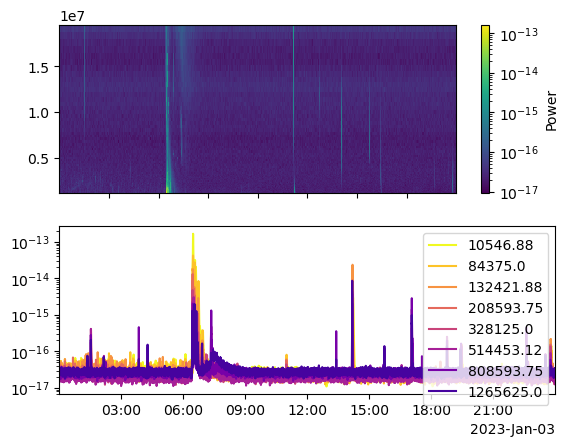

In [24]:
fig, ax = plt.subplots(nrows=2, sharex=True)

p = ax[0].pcolormesh(t_fits, f_fits.T, dyspec.T, norm=LogNorm())
plt.yscale('log')
plt.colorbar(p, label='Power')

# time_diff_hfr = np.ediff1d(times_hfr)
# time_diff_lfr = np.ediff1d(times_lfr)
# ax[2].plot(times[:-1], time_diff_hfr)
# ax[2].plot(times_low[:-1], time_diff_lfr)

actual_freq = freq_lfr[0, :]
colors = cm.plasma(np.linspace(0, 1, len(actual_freq)))
colors = colors[::-1]
for i in range(0, len(actual_freq), 8):
    ax[1].plot(t_fits, dyspec[:, i], label=actual_freq[i], color=colors[i])
ax[1].set_yscale('log')
ax[1].legend()
plt.show()

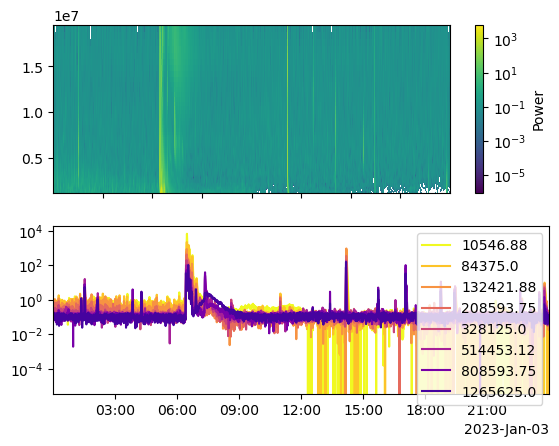

In [25]:
fig, ax = plt.subplots(nrows=2, sharex=True)

p = ax[0].pcolormesh(t_fits, f_fits.T, data_fits_new.T, norm=LogNorm())
plt.yscale('log')
plt.colorbar(p, label='Power')

# time_diff_hfr = np.ediff1d(times_hfr)
# time_diff_lfr = np.ediff1d(times_lfr)
# ax[2].plot(times[:-1], time_diff_hfr)
# ax[2].plot(times_low[:-1], time_diff_lfr)

actual_freq = freq_lfr[0, :]
colors = cm.plasma(np.linspace(0, 1, len(actual_freq)))
colors = colors[::-1]
for i in range(0, len(actual_freq), 8):
    ax[1].plot(t_fits, data_fits_new[:, i], label=actual_freq[i], color=colors[i])
ax[1].set_yscale('log')
ax[1].legend()
plt.show()

In [26]:
data_fits_new

array([[ 0.7944791 ,  0.80410284,  0.8090592 , ...,  0.17479737,
         0.18022884,  0.19737165],
       [ 0.7647904 ,  0.73466986,  0.6911938 , ...,  0.15462752,
         0.15313257,  0.1613816 ],
       [ 0.69499063,  0.6322739 ,  0.55163866, ...,  0.13211505,
         0.13134924,  0.13762507],
       ...,
       [ 0.06258968,  0.02374407, -0.00510197, ...,  0.06367572,
         0.08145941,  0.09655716],
       [ 0.10585406,  0.05292162,  0.02278415, ...,  0.05975614,
         0.07442607,  0.07596011],
       [ 0.1268733 ,  0.05740009,  0.03078409, ...,  0.06386932,
         0.06881358,  0.05215285]], dtype=float32)

In [27]:
def binarization(data_fits_new,N_order=2,peak_r=0.30):
    # with high order local-max method 
    # N_order = 5
    # peak_r = 0.95
    bmap = np.ones_like(data_fits_new)
    N_pad = N_order
    local_max_arr = np.pad(data_fits_new,((N_pad,N_pad),(0,0)))
    for idx in range(N_pad-1):
        bmap=bmap* ((peak_r*local_max_arr[N_pad+idx+1:-N_pad+idx+1,:]<
                            local_max_arr[N_pad+idx:-N_pad+idx,:]) & 
                    (peak_r*local_max_arr[N_pad-idx-1:-N_pad-idx-1,:]<
                            local_max_arr[N_pad-idx:-N_pad-idx,:]) )
    return bmap

bmap = binarization(dyspec)
bmap

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)

In [28]:
bmap.shape

(12359, 64)

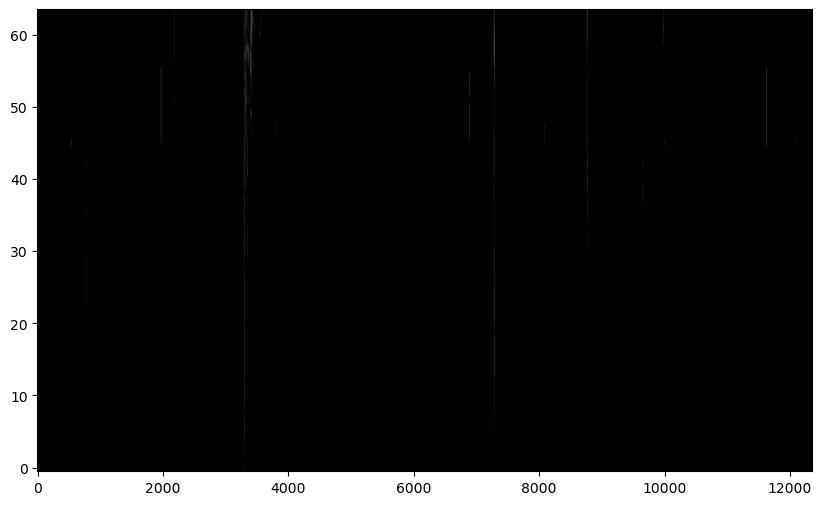

In [29]:
plt.figure(figsize=(10, 6))
plt.imshow(1-bmap.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

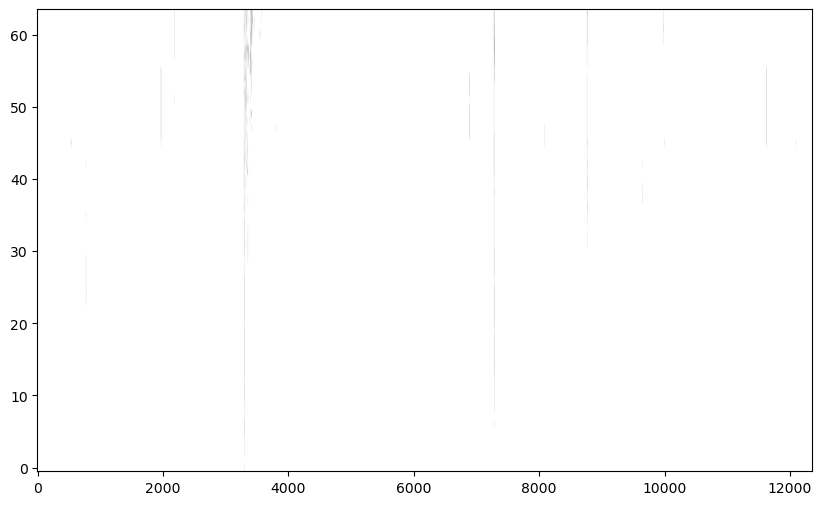

In [30]:
bmap_inv = np.logical_not(bmap)
plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_inv.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

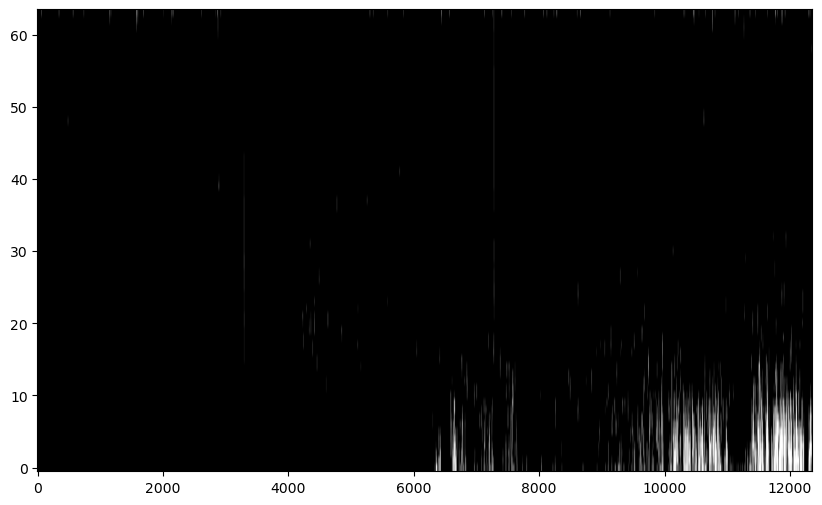

In [31]:
# preprocessed binarization
dyspec_preproc_binarized = binarization(data_fits_new)
plt.figure(figsize=(10, 6))
plt.imshow(1-dyspec_preproc_binarized.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

In [32]:
def hough_detect(bmap,dyspec,threshold=50,line_gap=10,line_length=25,
            theta=np.linspace(np.pi/2-np.pi/8,np.pi/2-1/180*np.pi,300)):
    threshold = 10
    line_gap = 50
    line_length = 10
    lines = probabilistic_hough_line(bmap, threshold=threshold,line_gap=line_gap,line_length=line_length,
                                 theta=theta)
    return lines

lines = hough_detect(bmap_inv, dyspec)
lines

[((0, 3309), (43, 3303)),
 ((2, 3309), (61, 3302)),
 ((9, 7294), (49, 7289)),
 ((18, 7292), (42, 7289)),
 ((6, 7295), (58, 7288)),
 ((31, 3334), (58, 3333)),
 ((39, 3333), (63, 3332)),
 ((11, 3308), (58, 3303)),
 ((45, 7290), (63, 7288)),
 ((13, 7292), (31, 7290)),
 ((31, 8778), (60, 8772)),
 ((50, 3336), (63, 3335)),
 ((32, 8777), (56, 8772)),
 ((15, 3306), (62, 3303)),
 ((45, 8773), (62, 8772)),
 ((3, 3309), (21, 3307)),
 ((27, 7290), (63, 7289)),
 ((42, 8774), (63, 8772)),
 ((37, 3317), (62, 3315))]

In [33]:
norm = np.linalg.norm
def point_to_line_distance(p1,p2,p3):
    d = np.abs(norm(np.cross(p2-p1, p1-p3)))/norm(p2-p1)
    return d

def point_to_point_distance(p1,p2):
    return norm(p1-p2)

In [34]:
def line_grouping(lines,min_dist=3, threshmode=2): # pix
    """
    Parameters
    ----------
    lines : list
        list of lines detected by hough transform.
    min_dist : float, optional  # pix
        minimum distance between two lines to be grouped together.
    threshmode : int, optional
        DESCRIPTION. 1: only distance of point to line
                        2: distance of point to line and angle between lines
    """
    # group the detected lines into group in regard of events
    lines = sorted(lines, key=lambda i: (i[0][1]+i[1][1])/2)
    line_sets = [[lines[0]]]
    for idx,line in enumerate(lines[0:-1]):
        (A,B),(C,D) = np.array([lines[idx], lines[idx+1] ])

        # use the longer line as the reference
        l_AB = norm(A-B)
        l_CD = norm(C-D)
        if l_AB<l_CD:
            A,B,C,D = C,D,A,B
        
        # point to line distance
        Line_dist_thresh = np.min([point_to_line_distance(A,B,C),point_to_line_distance(A,B,D)])< min_dist
        Line_dist_thresh2 = np.min([point_to_line_distance(A,B,C),point_to_line_distance(A,B,D)])< min_dist*1.5

        # two lines segment not too far away
        Point_dist_thresh = np.min([point_to_point_distance(A,C),point_to_point_distance(A,D),
                                    point_to_point_distance(B,C),point_to_point_distance(B,D)])< np.max(
                                        [point_to_point_distance(A,B),point_to_point_distance(C,D)])
       
        if threshmode==1:
            final_thresh = Line_dist_thresh
        elif threshmode==2:
            final_thresh = Line_dist_thresh & Point_dist_thresh
        elif threshmode==3:
            if B[0]>C[0] and B[1]>C[1]:
                final_thresh = Line_dist_thresh2 & Point_dist_thresh

        if final_thresh:
            # the line join
            line_sets[len(line_sets)-1].append(lines[idx+1])
        else:
            # new set
            line_sets.append([lines[idx+1]])
    
    return line_sets

line_sets = line_grouping(lines)
line_sets

[[((15, 3306), (62, 3303)),
  ((2, 3309), (61, 3302)),
  ((11, 3308), (58, 3303)),
  ((0, 3309), (43, 3303)),
  ((3, 3309), (21, 3307))],
 [((37, 3317), (62, 3315))],
 [((39, 3333), (63, 3332)),
  ((31, 3334), (58, 3333)),
  ((50, 3336), (63, 3335))],
 [((45, 7290), (63, 7288)),
  ((27, 7290), (63, 7289)),
  ((18, 7292), (42, 7289)),
  ((13, 7292), (31, 7290)),
  ((9, 7294), (49, 7289)),
  ((6, 7295), (58, 7288))],
 [((45, 8773), (62, 8772)),
  ((42, 8774), (63, 8772)),
  ((32, 8777), (56, 8772)),
  ((31, 8778), (60, 8772))]]

In [35]:
def get_info_from_linegroup(line_sets,t_fits,f_fits):

    # mapping from t and f to index of x and y
    t_idx_arr = np.arange(0, t_fits.shape[0])
    f_idx_arr = np.arange(0, f_fits.shape[0])
    t_interf = interpolate.interp1d(t_idx_arr, t_fits)
    f_interf = interpolate.interp1d(f_idx_arr, f_fits)
    
    v_beam = []
    f_range_burst = []
    t_range_burst = []
    model_curve_set = []
    t_set_arr_set = []
    f_set_arr_set = []
    t_set_arr = []
    f_set_arr = []
    t_model_arr = []
    f_model_arr = []
    print(line_sets)

    for lines in line_sets:
        if len(lines)==1:
            continue
        try:
            x_set=[]
            y_set=[]
            for line in lines:
                x_set.append(line[0][1])
                x_set.append(line[1][1])
                y_set.append(line[0][0])
                y_set.append(line[1][0])

            t_set_arr = (t_interf(x_set) - np.min(t_fits))*24*3600
            f_set_arr = f_interf(y_set)

            popt, pcov = optimize.curve_fit(rt.freq_drift_f_t,
                t_set_arr, f_set_arr, p0=(0.1,np.min(t_set_arr)-3./3600/24), method="lm")

            t_model_arr  = np.linspace(rt.freq_drift_t_f(np.min(f_set_arr),*popt) ,
                                       rt.freq_drift_t_f(np.max(f_set_arr),*popt),50) 
            f_model_arr = rt.freq_drift_f_t(t_model_arr,popt[0],popt[1])

            t_model_arr = t_model_arr/(24*3600)+np.min(t_fits)


            model_curve_set.append([t_model_arr,f_model_arr])
            t_range_burst.append( [rt.freq_drift_t_f(np.min(f_set_arr),*popt)[0]/(24*3600)+np.min(t_fits) ,
                                   rt.freq_drift_t_f(np.max(f_set_arr),*popt)[0]/(24*3600)+np.min(t_fits) ] )
            f_range_burst.append([np.min(f_set_arr),np.max(f_set_arr)])
            v_beam.append(popt[0])
            t_set_arr_set.append(t_set_arr)
            f_set_arr_set.append(f_set_arr)
        except Exception as e:
            print("Error in line_group:", e)

    
    return (v_beam, f_range_burst, t_range_burst, model_curve_set,
            t_set_arr_set,f_set_arr_set,
           t_model_arr,f_model_arr)

v_beam, f_range_burst, t_range_burst, model_curve_set, t_set_arr_set,f_set_arr_set, t_model_arr,f_model_arr = get_info_from_linegroup(line_sets,t_fits,f_fits)

[[((15, 3306), (62, 3303)), ((2, 3309), (61, 3302)), ((11, 3308), (58, 3303)), ((0, 3309), (43, 3303)), ((3, 3309), (21, 3307))], [((37, 3317), (62, 3315))], [((39, 3333), (63, 3332)), ((31, 3334), (58, 3333)), ((50, 3336), (63, 3335))], [((45, 7290), (63, 7288)), ((27, 7290), (63, 7289)), ((18, 7292), (42, 7289)), ((13, 7292), (31, 7290)), ((9, 7294), (49, 7289)), ((6, 7295), (58, 7288))], [((45, 8773), (62, 8772)), ((42, 8774), (63, 8772)), ((32, 8777), (56, 8772)), ((31, 8778), (60, 8772))]]
Error in line_group: ufunc 'subtract' cannot use operands with types dtype('float64') and dtype('<M8[ns]')
Error in line_group: ufunc 'subtract' cannot use operands with types dtype('float64') and dtype('<M8[ns]')
Error in line_group: ufunc 'subtract' cannot use operands with types dtype('float64') and dtype('<M8[ns]')
Error in line_group: ufunc 'subtract' cannot use operands with types dtype('float64') and dtype('<M8[ns]')


In [36]:
model_curve_set

[]

In [37]:
len(t_fits)

12359

In [38]:
len(f_fits)

64

In [39]:
times_hfr.shape

(12359,)

In [40]:
freq_hfr.shape

(12359, 64)

In [41]:
freq_hfr[0].shape

(64,)

In [42]:
t_fits.shape

(12359,)

In [43]:
f_fits.shape

(64,)

2023-01-03T06:25:15.013089536 2023-01-03T06:24:54.041407872 2371875.0 18375000.0
2023-01-03T06:25:35.984526976 2023-01-03T06:24:47.050928640 1378125.0 17625000.0
2023-01-03T06:25:28.994047872 2023-01-03T06:24:54.041407872 2025000.0 15478125.0
2023-01-03T06:25:35.984526976 2023-01-03T06:24:54.041407872 1275000.0 8071875.0
2023-01-03T06:25:35.984526976 2023-01-03T06:25:22.003568640 1425000.0 3121875.0
2023-01-03T06:26:31.908604800 2023-01-03T06:26:17.927646464 6225000.0 18375000.0
2023-01-03T06:28:23.757004032 2023-01-03T06:28:16.766280832 6778125.0 19171876.0
2023-01-03T06:28:30.747483264 2023-01-03T06:28:23.757004032 4771875.0 15478125.0
2023-01-03T06:28:44.728441600 2023-01-03T06:28:37.737962368 10921875.0 19171876.0
2023-01-03T14:09:25.226438272 2023-01-03T14:09:11.245479936 8821875.0 19171876.0
2023-01-03T14:09:25.226438272 2023-01-03T14:09:18.235959168 4021875.0 19171876.0
2023-01-03T14:09:39.207640832 2023-01-03T14:09:18.235959168 2728125.0 7725000.0
2023-01-03T14:09:39.207640832 

<Figure size 1000x600 with 0 Axes>

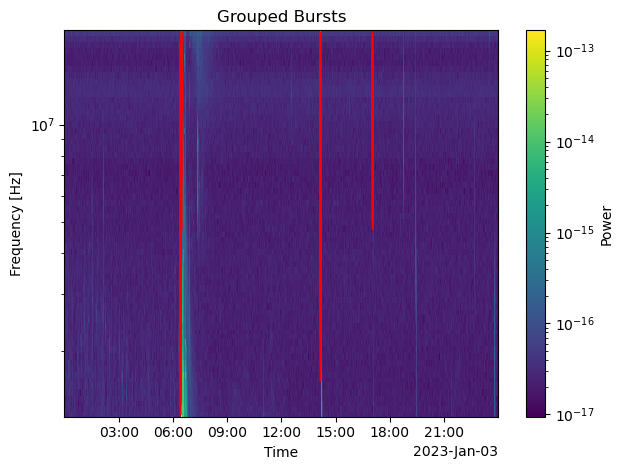

In [87]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, freq_hfr[0], data_hfr.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for line_group in line_sets:
    for (x0, y0), (x1, y1) in line_group:
        t0, t1 = t_fits[y0], t_fits[y1]
        f0, f1 = f_fits[x0], f_fits[x1]
        print(t0, t1, f0, f1)
        ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()